In [84]:
#monuting drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##Validation data set

In [85]:
#importing validation_data set

import pandas as pd

validation_data= pd.read_csv("/content/drive/MyDrive/Data science project/Hotel-A-validation.csv")



In [86]:
print(validation_data.isnull().sum())

Reservation-id            0
Gender                    0
Age                       0
Ethnicity                 0
Educational_Level         0
Income                    0
Country_region            0
Hotel_Type                0
Expected_checkin          0
Expected_checkout         0
Booking_date              0
Adults                    0
Children                  0
Babies                    0
Meal_Type                 0
Visted_Previously         0
Previous_Cancellations    0
Deposit_type              0
Booking_channel           0
Required_Car_Parking      0
Reservation_Status        0
Use_Promotion             0
Discount_Rate             0
Room_Rate                 0
dtype: int64


In [87]:
#Checking for duplicating entries after dropping ID column

# Temporarily drop 'Reservation-id' to check for duplicate entries
validation_data_no_id = validation_data.drop(columns=['Reservation-id'])

duplicate_rows_count = validation_data_no_id.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_rows_count}")

Number of duplicate rows: 0


In [88]:
validation_data.dtypes

,0
Reservation-id,int64
Gender,object
Age,int64
Ethnicity,object
Educational_Level,object
Income,object
Country_region,object
Hotel_Type,object
Expected_checkin,object
Expected_checkout,object


In [89]:
#Convert Date columns to Datetime objects
date_cols = ['Expected_checkin', 'Expected_checkout', 'Booking_date']
for col in date_cols:
    validation_data[col] = pd.to_datetime(validation_data[col], errors='coerce')


validation_data.dtypes

,0
Reservation-id,int64
Gender,object
Age,int64
Ethnicity,object
Educational_Level,object
Income,object
Country_region,object
Hotel_Type,object
Expected_checkin,datetime64[ns]
Expected_checkout,datetime64[ns]


In [90]:
validation_data["Reservation-id"].duplicated().sum()


np.int64(0)

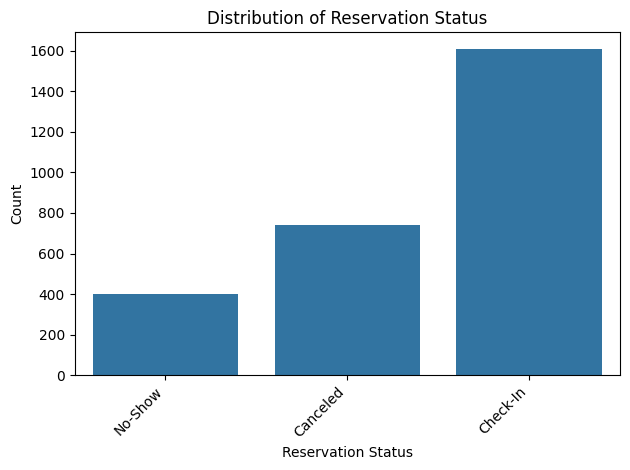

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(data=validation_data, x='Reservation_Status')
plt.title('Distribution of Reservation Status')
plt.xlabel('Reservation Status')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [92]:
# Identify "Time-Travel" Issues
# Issue A: Checking in before you even booked the room
issue_a = validation_data[validation_data['Expected_checkin'] < validation_data['Booking_date']]

# Issue B: Checking out before you checked in
issue_b = validation_data[validation_data['Expected_checkin'] > validation_data['Expected_checkout']]

# 3. Combine and Report
time_anomalies = pd.concat([issue_a, issue_b]).drop_duplicates()

print(f"Total rows with booking/check-in overlap: {len(issue_a)}")
print(f"Total rows with check-in/checkout overlap: {len(issue_b)}")
print(f"Total unique anomaly rows found: {len(time_anomalies)}")

Total rows with booking/check-in overlap: 16
Total rows with check-in/checkout overlap: 0
Total unique anomaly rows found: 16


In [93]:
validation_data = validation_data.drop(time_anomalies.index, errors='ignore')
print(validation_data.shape)
validation_data.head()

(2733, 24)


,Reservation-id,Gender,Age,Ethnicity,Educational_Level,Income,Country_region,Hotel_Type,Expected_checkin,Expected_checkout,...,Meal_Type,Visted_Previously,Previous_Cancellations,Deposit_type,Booking_channel,Required_Car_Parking,Reservation_Status,Use_Promotion,Discount_Rate,Room_Rate
0,45716350,M,56,caucasian,Grad,<25K,West,Resort,2016-08-31,2016-09-02,...,HB,No,No,No Deposit,Agent,No,No-Show,Yes,15,192
1,88857401,M,60,Latino,College,25K --50K,West,Resort,2016-08-31,2016-09-04,...,FB,Yes,No,No Deposit,Online,Yes,Canceled,No,0,187
2,16074440,F,58,Asian American,College,<25K,North,Airport Hotels,2016-09-01,2016-09-02,...,FB,No,No,No Deposit,Direct,No,Canceled,Yes,10,227
3,10992124,F,23,Latino,College,25K --50K,East,Airport Hotels,2016-08-31,2016-09-02,...,FB,Yes,No,Refundable,Direct,No,Check-In,Yes,25,189
4,15934351,F,47,Asian American,College,25K --50K,South,City Hotel,2016-08-31,2016-09-01,...,HB,Yes,No,No Deposit,Online,Yes,Check-In,Yes,10,218


In [94]:
# 1. Check for 'Adult-less' check-ins (Children/Babies but 0 Adults)
adultless_bookings = validation_data[(validation_data['Adults'] == 0) & ((validation_data['Children'] > 0) | (validation_data['Babies'] > 0))]
print(f"Number of bookings with children/babies but 0 adults: {len(adultless_bookings)}")

# 2. Check for 'Ghost' bookings (Total Guests = 0)
# We calculate a temporary total to check before we drop the originals
temp_total = validation_data['Adults'] + validation_data['Children'] + validation_data['Babies']
ghost_bookings = validation_data[temp_total == 0]
print(f"Number of bookings with 0 total guests: {len(ghost_bookings)}")

Number of bookings with children/babies but 0 adults: 0
Number of bookings with 0 total guests: 0


In [95]:
# Calculate Lead Time (Days between booking and arrival)
validation_data['Lead_Time'] = (validation_data['Expected_checkin'] - validation_data['Booking_date']).dt.days

# Calculate Total Nights (Duration of stay)
validation_data['Total Nights'] = (validation_data['Expected_checkout'] - validation_data['Expected_checkin']).dt.days

validation_data[['Lead_Time', 'Total Nights']]

,Lead_Time,Total Nights
0,195,2
1,175,4
2,193,1
3,103,2
4,92,1
...,...,...
2744,37,3
2745,154,1
2746,30,2
2747,170,1


In [96]:

# Extract Month (1-12) and Day of Week (0=Monday, 6=Sunday)
validation_data['Checkin_Month'] = validation_data['Expected_checkin'].dt.month
validation_data['Checkin_Day_of_Week'] = validation_data['Expected_checkin'].dt.dayofweek

# Optional: Is it a weekend? (1 if Saturday/Sunday, else 0)
validation_data['Is_Weekend'] = validation_data['Checkin_Day_of_Week'].apply(lambda x: 1 if x >= 5 else 0)

validation_data[['Checkin_Month', 'Checkin_Day_of_Week','Is_Weekend']]

,Checkin_Month,Checkin_Day_of_Week,Is_Weekend
0,8,2,0
1,8,2,0
2,9,3,0
3,8,2,0
4,8,2,0
...,...,...,...
2744,11,4,0
2745,12,4,0
2746,11,4,0
2747,11,4,0


In [97]:
#Total guests

validation_data['Total_Guests'] = validation_data['Adults'] + validation_data['Children'] + validation_data['Babies']

validation_data[['Total_Guests']]

,Total_Guests
0,4
1,4
2,4
3,3
4,2
...,...
2744,7
2745,5
2746,5
2747,6


In [98]:
# Loop through each column in the validation dataset
for col in validation_data.columns:
    unique_vals = validation_data[col].unique()
    print(f"Column: {col}")
    print(f"Unique Values ({len(unique_vals)}): {unique_vals}")
    print("-" * 30)

Column: Reservation-id
Unique Values (2733): [45716350 88857401 16074440 ... 31908733 41776403  5961678]
------------------------------
Column: Gender
Unique Values (2): ['M' 'F']
------------------------------
Column: Age
Unique Values (53): [56 60 58 23 47 59 48 32 57 38 46 20 61 35 19 21 67 64 62 42 18 24 70 26
 27 50 51 30 55 69 54 37 49 68 52 65 45 41 53 63 66 40 33 31 39 25 44 34
 29 22 43 36 28]
------------------------------
Column: Ethnicity
Unique Values (4): ['caucasian' 'Latino' 'Asian American' 'African American']
------------------------------
Column: Educational_Level
Unique Values (4): ['Grad' 'College' 'High-School' 'Mid-School']
------------------------------
Column: Income
Unique Values (4): ['<25K' '25K --50K' '50K -- 100K' '>100K']
------------------------------
Column: Country_region
Unique Values (4): ['West' 'North' 'East' 'South']
------------------------------
Column: Hotel_Type
Unique Values (3): ['Resort' 'Airport Hotels' 'City Hotel']
----------------------

In [99]:
validation_data['Reservation_Status'] = validation_data['Reservation_Status'].replace('Check-In', 'Check-Out')

# Verify the change
print(validation_data['Reservation_Status'].value_counts())

Reservation_Status
Check-Out    1602
Canceled      738
No-Show       393
Name: count, dtype: int64


In [100]:
#Dropping unwanted reservation id column

validation_data_ML = validation_data.drop(columns=['Reservation-id'])
print(validation_data_ML.shape)

(2733, 29)


In [101]:
#Dropping date time attributes

date_cols = ['Expected_checkin', 'Expected_checkout', 'Booking_date']
validation_data_ML = validation_data_ML.drop(columns=date_cols)

print(validation_data_ML.shape)

(2733, 26)


In [102]:
 file_path = '/content/drive/MyDrive/Data science project/ML/validation_data_cleaned_V2_ML.csv'
validation_data_ML.to_csv(file_path, index=False)

##Test data set

In [103]:
#importing test_data set

import pandas as pd

test_data= pd.read_csv("/content/drive/MyDrive/Data science project/Hotel-A-test.csv")



In [104]:
print(test_data.isnull().sum())

Reservation-id            0
Gender                    0
Age                       0
Ethnicity                 0
Educational_Level         0
Income                    0
Country_region            0
Hotel_Type                0
Expected_checkin          0
Expected_checkout         0
Booking_date              0
Adults                    0
Children                  0
Babies                    0
Meal_Type                 0
Visted_Previously         0
Previous_Cancellations    0
Deposit_type              0
Booking_channel           0
Required_Car_Parking      0
Use_Promotion             0
Discount_Rate             0
Room_Rate                 0
dtype: int64


In [105]:
#Checking for duplicating entries after dropping ID column

# Temporarily drop 'Reservation-id' to check for duplicate entries
test_data_no_id = test_data.drop(columns=['Reservation-id'])

duplicate_rows_count = test_data_no_id.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_rows_count}")

Number of duplicate rows: 0


In [106]:
test_data.dtypes

,0
Reservation-id,int64
Gender,object
Age,int64
Ethnicity,object
Educational_Level,object
Income,object
Country_region,object
Hotel_Type,object
Expected_checkin,object
Expected_checkout,object


In [107]:
#Convert Date columns to Datetime objects
date_cols = ['Expected_checkin', 'Expected_checkout', 'Booking_date']
for col in date_cols:
    test_data[col] = pd.to_datetime(test_data[col], errors='coerce')


test_data.dtypes

,0
Reservation-id,int64
Gender,object
Age,int64
Ethnicity,object
Educational_Level,object
Income,object
Country_region,object
Hotel_Type,object
Expected_checkin,datetime64[ns]
Expected_checkout,datetime64[ns]


In [108]:
test_data["Reservation-id"].duplicated().sum()


np.int64(0)

In [109]:
# Identify "Time-Travel" Issues
# Issue A: Checking in before you even booked the room
issue_a = test_data[test_data['Expected_checkin'] < test_data['Booking_date']]

# Issue B: Checking out before you checked in
issue_b = test_data[test_data['Expected_checkin'] > test_data['Expected_checkout']]

# 3. Combine and Report
time_anomalies = pd.concat([issue_a, issue_b]).drop_duplicates()

print(f"Total rows with booking/check-in overlap: {len(issue_a)}")
print(f"Total rows with check-in/checkout overlap: {len(issue_b)}")
print(f"Total unique anomaly rows found: {len(time_anomalies)}")

Total rows with booking/check-in overlap: 27
Total rows with check-in/checkout overlap: 0
Total unique anomaly rows found: 27


In [110]:
test_data = test_data.drop(time_anomalies.index, errors='ignore')
print(test_data.shape)
test_data.head()

(4291, 23)


,Reservation-id,Gender,Age,Ethnicity,Educational_Level,Income,Country_region,Hotel_Type,Expected_checkin,Expected_checkout,...,Babies,Meal_Type,Visted_Previously,Previous_Cancellations,Deposit_type,Booking_channel,Required_Car_Parking,Use_Promotion,Discount_Rate,Room_Rate
0,62931593,F,52,Latino,Grad,25K --50K,South,City Hotel,2016-11-18,2016-11-19,...,0,HB,No,No,No Deposit,Direct,Yes,Yes,10,153
1,70586099,F,47,Latino,Grad,25K --50K,East,Airport Hotels,2016-11-18,2016-11-19,...,0,FB,No,No,No Deposit,Online,No,No,0,210
2,4230648,F,28,Asian American,Grad,<25K,East,City Hotel,2017-04-28,2017-05-01,...,0,BB,No,No,No Deposit,Agent,No,Yes,5,117
3,25192322,F,65,caucasian,High-School,25K --50K,South,Airport Hotels,2016-11-18,2016-11-20,...,2,FB,No,No,No Deposit,Online,Yes,Yes,10,107
4,80931528,M,45,African American,College,25K --50K,South,City Hotel,2016-11-18,2016-11-20,...,0,BB,No,No,Refundable,Agent,No,No,0,119


In [111]:
# 1. Check for 'Adult-less' check-ins (Children/Babies but 0 Adults)
adultless_bookings = test_data[(test_data['Adults'] == 0) & ((test_data['Children'] > 0) | (test_data['Babies'] > 0))]
print(f"Number of bookings with children/babies but 0 adults: {len(adultless_bookings)}")

# 2. Check for 'Ghost' bookings (Total Guests = 0)
# We calculate a temporary total to check before we drop the originals
temp_total = test_data['Adults'] + test_data['Children'] + test_data['Babies']
ghost_bookings = test_data[temp_total == 0]
print(f"Number of bookings with 0 total guests: {len(ghost_bookings)}")

Number of bookings with children/babies but 0 adults: 0
Number of bookings with 0 total guests: 0


In [112]:
# Calculate Lead Time (Days between booking and arrival)
test_data['Lead_Time'] = (test_data['Expected_checkin'] - test_data['Booking_date']).dt.days

# Calculate Total Nights (Duration of stay)
test_data['Total Nights'] = (test_data['Expected_checkout'] - test_data['Expected_checkin']).dt.days

test_data[['Lead_Time', 'Total Nights']]

,Lead_Time,Total Nights
0,21,1
1,104,1
2,20,3
3,182,2
4,18,2
...,...,...
4313,199,1
4314,47,3
4315,215,1
4316,25,1


In [113]:

# Extract Month (1-12) and Day of Week (0=Monday, 6=Sunday)
test_data['Checkin_Month'] = test_data['Expected_checkin'].dt.month
test_data['Checkin_Day_of_Week'] = test_data['Expected_checkin'].dt.dayofweek

# Optional: Is it a weekend? (1 if Saturday/Sunday, else 0)
test_data['Is_Weekend'] = test_data['Checkin_Day_of_Week'].apply(lambda x: 1 if x >= 5 else 0)

test_data[['Checkin_Month', 'Checkin_Day_of_Week','Is_Weekend']]

,Checkin_Month,Checkin_Day_of_Week,Is_Weekend
0,11,4,0
1,11,4,0
2,4,4,0
3,11,4,0
4,11,4,0
...,...,...,...
4313,3,2,0
4314,3,2,0
4315,3,2,0
4316,3,2,0


In [114]:
#Total guests

test_data['Total_Guests'] = test_data['Adults'] + test_data['Children'] + test_data['Babies']

test_data[['Total_Guests']]

,Total_Guests
0,6
1,3
2,4
3,6
4,4
...,...
4313,7
4314,6
4315,5
4316,7


In [115]:
#Dropping unwanted reservation id column

test_data_ML = test_data.drop(columns=['Reservation-id'])
print(test_data_ML.shape)

(4291, 28)


In [116]:
#Dropping date time attributes

date_cols = ['Expected_checkin', 'Expected_checkout', 'Booking_date']
test_data_ML = test_data_ML.drop(columns=date_cols)

print(test_data_ML.shape)

(4291, 25)


In [117]:
# Loop through each column in the validation dataset
for col in test_data.columns:
    unique_vals = test_data[col].unique()
    print(f"Column: {col}")
    print(f"Unique Values ({len(unique_vals)}): {unique_vals}")
    print("-" * 30)

Column: Reservation-id
Unique Values (4291): [62931593 70586099  4230648 ... 59004046 65838682 14474101]
------------------------------
Column: Gender
Unique Values (2): ['F' 'M']
------------------------------
Column: Age
Unique Values (53): [52 47 28 65 45 26 27 40 44 48 49 57 61 29 39 55 33 18 25 50 19 31 60 66
 59 21 68 67 43 38 20 42 69 62 51 54 34 35 37 63 32 24 58 41 46 64 30 22
 23 36 70 53 56]
------------------------------
Column: Ethnicity
Unique Values (4): ['Latino' 'Asian American' 'caucasian' 'African American']
------------------------------
Column: Educational_Level
Unique Values (4): ['Grad' 'High-School' 'College' 'Mid-School']
------------------------------
Column: Income
Unique Values (4): ['25K --50K' '<25K' '>100K' '50K -- 100K']
------------------------------
Column: Country_region
Unique Values (4): ['South' 'East' 'West' 'North']
------------------------------
Column: Hotel_Type
Unique Values (3): ['City Hotel' 'Airport Hotels' 'Resort']
----------------------

In [118]:
 file_path = '/content/drive/MyDrive/Data science project/ML/test_data_cleaned_V2_ML.csv'
test_data_ML.to_csv(file_path, index=False)